# Pretrained Models Tutorial - AnimalCLEF 2026

This notebook demonstrates how to use pretrained models for the AnimalCLEF 2026 competition:
- **MegaDescriptor**: Foundation model for wildlife re-identification
- **ResNet**: Custom re-identification model
- **MPS Acceleration**: Leveraging Mac GPU (Apple Silicon)

**Goals:**
1. Load and use both models
2. Extract embeddings for similarity search
3. Compare model performance
4. Optimize for MPS (Mac GPU)
5. Build practical re-identification pipeline

## 1. Setup & Environment Check

In [1]:
import sys
sys.path.append('..')

import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
import time
from typing import List, Tuple
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
%matplotlib inline

In [2]:
# Check PyTorch version and device availability
print("=" * 70)
print("🔧 Environment Information")
print("=" * 70)
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print()

# Check device availability
print("📱 Device Availability:")
print(f"  MPS (Metal) available: {torch.backends.mps.is_available()}")
print(f"  MPS built: {torch.backends.mps.is_built()}")
print(f"  CUDA available: {torch.cuda.is_available()}")
print()

# Set device (MPS for Mac, CUDA for GPU, CPU as fallback)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using MPS (Apple Silicon GPU)")
    print("   This will significantly speed up inference!")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("⚠️  Using CPU (slower)")
    print("   Consider using a GPU for better performance")

print(f"\nDevice: {device}")
print("=" * 70)

🔧 Environment Information
PyTorch version: 2.10.0
Torchvision version: 0.25.0

📱 Device Availability:
  MPS (Metal) available: True
  MPS built: True
  CUDA available: False

✅ Using MPS (Apple Silicon GPU)
   This will significantly speed up inference!

Device: mps


## 2. Model Overview & Comparison

Let's compare the two main approaches for this competition:

### MegaDescriptor vs ResNet Comparison

| Feature | MegaDescriptor | ResNet (Custom) |
|---------|---------------|----------------|
| **Architecture** | Swin Transformer (hierarchical ViT) | CNN-based (Residual Network) |
| **Input Size** | 384 × 384 (flexible) | 224 × 224 (standard) |
| **Embedding Dim** | 1536 | 512 (customizable) |
| **Pretrained On** | Wildlife datasets (50+ species) | ImageNet |
| **Training Data** | Diverse wildlife (10M+ images) | General objects (1M images) |
| **Best For** | Zero-shot, cross-species | Fine-tuning, custom training |
| **Pros** | Strong baseline, no training needed | Flexible, faster inference |
| **Cons** | Larger model, slower | Requires training data |
| **Recommended** | ✅ Start here | Fine-tuning later |

### When to Use Each Model

**MegaDescriptor (Recommended for this competition):**
- Strong baseline without training
- Handles diverse species well
- Pre-trained on wildlife data
- Good for zero-shot scenarios

**ResNet (For advanced users):**
- Custom training with metric learning
- Fine-tuning on competition data
- Faster inference requirements
- Ensemble with MegaDescriptor

## 3. Loading Sample Data

In [3]:
# Load metadata
metadata = pd.read_csv('../data/raw/metadata.csv')
print(f"Total images: {len(metadata)}")
print(f"Datasets: {metadata['dataset'].unique()}")
print()

# Dataset distribution
print("Images per dataset:")
print(metadata['dataset'].value_counts())

Total images: 15483
Datasets: <ArrowStringArray>
['LynxID2025', 'SalamanderID2025', 'SeaTurtleID2022', 'TexasHornedLizards']
Length: 4, dtype: str

Images per dataset:
dataset
SeaTurtleID2022       9229
LynxID2025            3903
SalamanderID2025      2077
TexasHornedLizards     274
Name: count, dtype: int64


In [4]:
# Sample images from each dataset for testing
sample_images = {}
base_path = Path('../data/raw')

for dataset in metadata['dataset'].unique():
    dataset_df = metadata[metadata['dataset'] == dataset]
    # Sample from training set only
    train_df = dataset_df[dataset_df['split'] == 'train']
    if len(train_df) > 0:
        sample = train_df.sample(n=min(5, len(train_df)), random_state=42)
        sample_images[dataset] = sample
        print(f"{dataset}: {len(sample)} samples")

LynxID2025: 5 samples
SalamanderID2025: 5 samples
SeaTurtleID2022: 5 samples


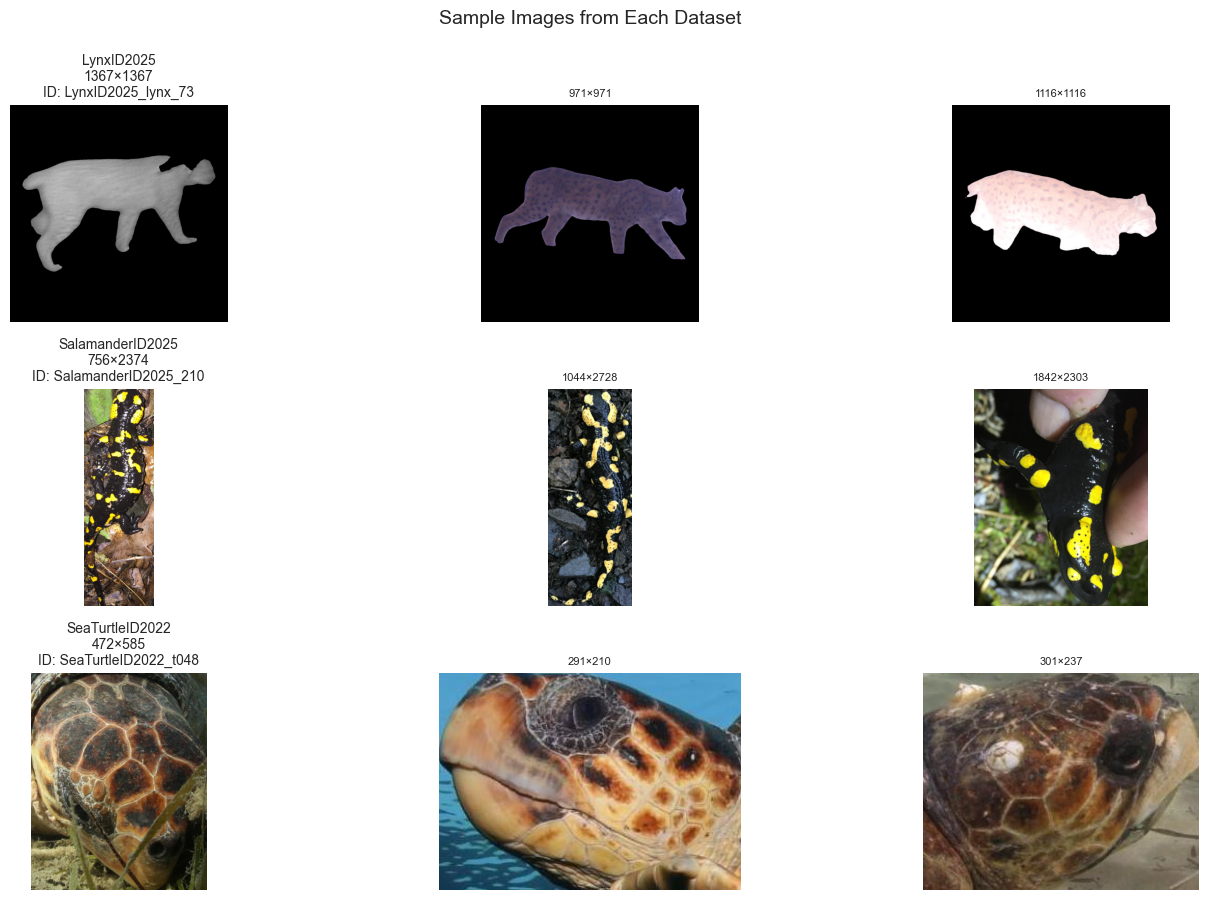

In [5]:
# Visualize sample images
def plot_sample_images(sample_dict, base_path, num_samples=3):
    """Plot sample images from each dataset"""
    datasets = list(sample_dict.keys())
    fig, axes = plt.subplots(len(datasets), num_samples, figsize=(15, len(datasets) * 3))
    
    for i, dataset_name in enumerate(datasets):
        samples = sample_dict[dataset_name].head(num_samples)
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img_path = base_path / row['path']
            if img_path.exists():
                img = Image.open(img_path).convert('RGB')
                
                if len(datasets) == 1:
                    ax = axes[j]
                else:
                    ax = axes[i, j]
                
                ax.imshow(img)
                ax.axis('off')
                if j == 0:
                    title = f"{dataset_name}\n{img.size[0]}×{img.size[1]}"
                    if not pd.isna(row['identity']):
                        title += f"\nID: {row['identity']}"
                    ax.set_title(title, fontsize=10)
                else:
                    ax.set_title(f"{img.size[0]}×{img.size[1]}", fontsize=8)
    
    plt.suptitle('Sample Images from Each Dataset', fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

plot_sample_images(sample_images, base_path, num_samples=3)

## 4. MegaDescriptor Model Tutorial

MegaDescriptor is a foundation model specifically designed for wildlife re-identification. It's pre-trained on diverse wildlife datasets and provides strong zero-shot performance.

### A. Loading the MegaDescriptor Model

In [6]:
import timm
from wildlife_tools.features.deep import DeepFeatures

print("Loading MegaDescriptor model...")
print("(First run will download the model from HuggingFace - ~500MB)")
print()

# Load MegaDescriptor model from HuggingFace Hub
model_name = 'hf-hub:BVRA/MegaDescriptor-L-384'
backbone_model = timm.create_model(model_name, pretrained=True, num_classes=0)

print(f"✓ Backbone loaded: {model_name}")
print()

# Create feature extractor with MPS support
megadescriptor = DeepFeatures(
    model=backbone_model,
    device=str(device),  # 'mps', 'cuda', or 'cpu'
    batch_size=1,
    num_workers=0
)

print("✅ MegaDescriptor loaded successfully!")
print(f"   Device: {device}")
print(f"   Model: MegaDescriptor-L-384 (Large, 384×384)")
print(f"   Embedding dimension: 1536")
print()
print("💡 Note: DeepFeatures works with PyTorch datasets.")
print("   For single image inference, we'll create helper functions.")

Loading MegaDescriptor model...
(First run will download the model from HuggingFace - ~500MB)

✓ Backbone loaded: hf-hub:BVRA/MegaDescriptor-L-384

✅ MegaDescriptor loaded successfully!
   Device: mps
   Model: MegaDescriptor-L-384 (Large, 384×384)
   Embedding dimension: 1536

💡 Note: DeepFeatures works with PyTorch datasets.
   For single image inference, we'll create helper functions.


### B. Image Preprocessing

MegaDescriptor has built-in preprocessing, but let's understand what's happening:

In [7]:
# MegaDescriptor preprocessing details
print("MegaDescriptor Preprocessing:")
print("=" * 50)
print("Input:")
print("  - PIL Image or PyTorch tensor")
print("  - RGB format")
print("  - Any size (will be resized)")
print()
print("Preprocessing Pipeline:")
print("  - Resize to 384×384 (MegaDescriptor-L-384)")
print("  - Convert to tensor [0, 1]")
print("  - Normalize with ImageNet statistics:")
print("    • Mean: [0.485, 0.456, 0.406]")
print("    • Std:  [0.229, 0.224, 0.225]")
print()
print("Output:")
print("  - Embedding vector [1536 dimensions]")
print("  - Not L2 normalized by default")
print()
print("💡 Tip: Model is loaded from HuggingFace Hub (BVRA/MegaDescriptor-L-384)")
print("   Other variants: MegaDescriptor-S/B/T with 224 or 384 input size")

MegaDescriptor Preprocessing:
Input:
  - PIL Image or PyTorch tensor
  - RGB format
  - Any size (will be resized)

Preprocessing Pipeline:
  - Resize to 384×384 (MegaDescriptor-L-384)
  - Convert to tensor [0, 1]
  - Normalize with ImageNet statistics:
    • Mean: [0.485, 0.456, 0.406]
    • Std:  [0.229, 0.224, 0.225]

Output:
  - Embedding vector [1536 dimensions]
  - Not L2 normalized by default

💡 Tip: Model is loaded from HuggingFace Hub (BVRA/MegaDescriptor-L-384)
   Other variants: MegaDescriptor-S/B/T with 224 or 384 input size


### C. Feature Extraction with MegaDescriptor

Testing feature extraction on: 5ea96ecfb746c2f00451dcd4b6a3547dda16b9809aab1784a670acf0a73e6966.jpg



100%|█████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.77s/it]

✅ Feature extraction successful!
   Embedding shape: (1, 1536)
   Time: 2.529 seconds
   Embedding norm: 9.8700


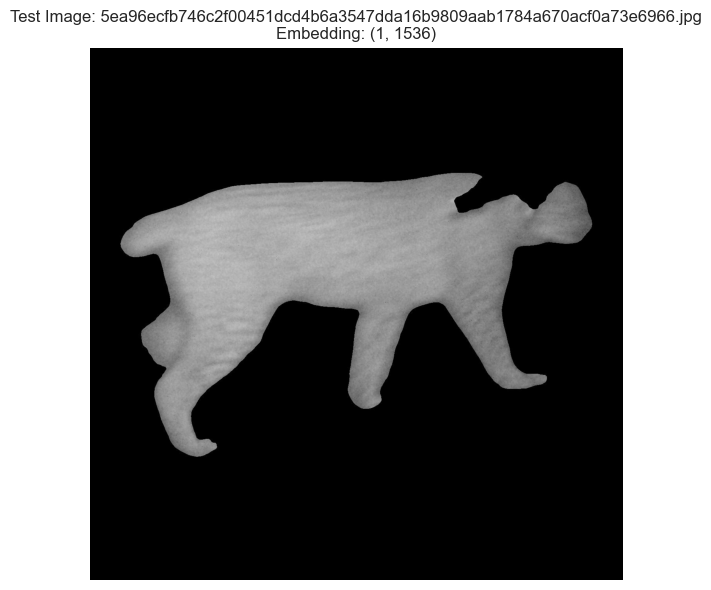

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Create a simple dataset for MegaDescriptor
class SimpleImageDataset(Dataset):
    """Simple dataset for loading images"""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform or transforms.Compose([
            transforms.Resize((384, 384)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        img_tensor = self.transform(img)
        return img_tensor, 0  # Return dummy label

def extract_features_megadescriptor(image_paths: List[Path], feature_extractor) -> np.ndarray:
    """
    Extract embeddings using MegaDescriptor
    
    Args:
        image_paths: List of image file paths
        feature_extractor: DeepFeatures instance
    
    Returns:
        embeddings: Array of shape [N, embedding_dim]
    """
    # Create dataset
    dataset = SimpleImageDataset(image_paths)
    
    # Extract features using the feature extractor
    embeddings = feature_extractor(dataset)
    
    return embeddings

# Test on a single image
test_dataset = list(sample_images.keys())[0]
test_row = sample_images[test_dataset].iloc[0]
test_image_path = base_path / test_row['path']

print(f"Testing feature extraction on: {test_image_path.name}")
print()

# Extract features
start_time = time.time()
embedding = extract_features_megadescriptor([test_image_path], megadescriptor)
elapsed = time.time() - start_time

print(f"✅ Feature extraction successful!")
print(f"   Embedding shape: {embedding.shape}")
print(f"   Time: {elapsed:.3f} seconds")
print(f"   Embedding norm: {np.linalg.norm(embedding):.4f}")

# Show the image
img = Image.open(test_image_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f'Test Image: {test_image_path.name}\nEmbedding: {embedding.shape}')
plt.tight_layout()
plt.show()

### D. Similarity Search Demo

In [9]:
# Extract embeddings for all sample images from one dataset
demo_dataset = 'LynxID2025'  # Change to any dataset
demo_samples = sample_images[demo_dataset]

print(f"Extracting features for {len(demo_samples)} images from {demo_dataset}...")
print()

image_paths = [base_path / path for path in demo_samples['path']]
image_ids = demo_samples['identity'].values

# Extract features
start_time = time.time()
embeddings = extract_features_megadescriptor(image_paths, megadescriptor)
elapsed = time.time() - start_time

print(f"✅ Extracted {len(embeddings)} embeddings")
print(f"   Shape: {embeddings.shape}")
print(f"   Time: {elapsed:.3f} seconds ({elapsed/len(embeddings):.3f} sec/image)")

Extracting features for 5 images from LynxID2025...



100%|█████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  9.66it/s]

✅ Extracted 5 embeddings
   Shape: (5, 1536)
   Time: 0.523 seconds (0.105 sec/image)


Similarity matrix shape: (5, 5)



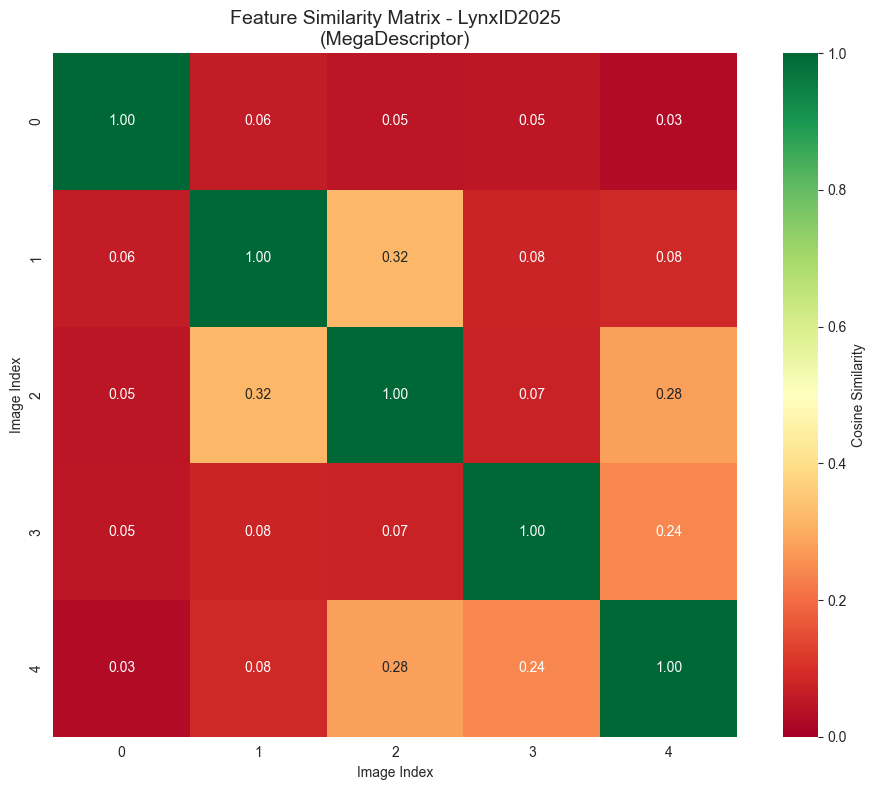

💡 Interpretation:
  - Diagonal = 1.0 (same image)
  - High similarity (>0.8) = likely same individual
  - Low similarity (<0.6) = likely different individuals


In [10]:
# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings, embeddings)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print()

# Visualize similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            vmin=0.0, 
            vmax=1.0,
            square=True,
            cbar_kws={'label': 'Cosine Similarity'})
plt.title(f'Feature Similarity Matrix - {demo_dataset}\n(MegaDescriptor)', fontsize=14)
plt.xlabel('Image Index')
plt.ylabel('Image Index')
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("  - Diagonal = 1.0 (same image)")
print("  - High similarity (>0.8) = likely same individual")
print("  - Low similarity (<0.6) = likely different individuals")

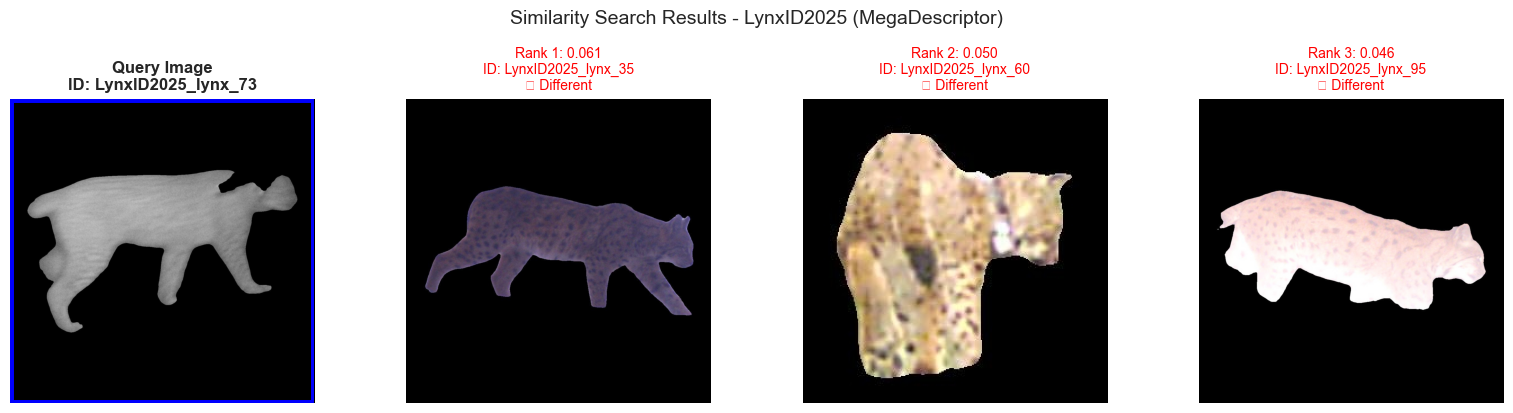


Query: LynxID2025_lynx_73
Top-3 Results:
  1. ✗ ID: LynxID2025_lynx_35 - Similarity: 0.0613
  2. ✗ ID: LynxID2025_lynx_60 - Similarity: 0.0502
  3. ✗ ID: LynxID2025_lynx_95 - Similarity: 0.0457


In [11]:
# Find most similar images
def find_similar_images(query_idx: int, similarity_matrix: np.ndarray, top_k: int = 3):
    """
    Find top-k most similar images to query
    
    Args:
        query_idx: Index of query image
        similarity_matrix: Similarity matrix [N, N]
        top_k: Number of similar images to return
    
    Returns:
        indices: Indices of top-k similar images
        scores: Similarity scores
    """
    similarities = similarity_matrix[query_idx].copy()
    similarities[query_idx] = -1  # Exclude self
    
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    return top_indices, top_scores

# Test similarity search
query_idx = 0
top_k = 3

top_indices, top_scores = find_similar_images(query_idx, similarity_matrix, top_k=top_k)

# Visualize results
fig, axes = plt.subplots(1, top_k + 1, figsize=(16, 4))

# Query image
query_img = Image.open(image_paths[query_idx])
axes[0].imshow(query_img)
axes[0].axis('off')
axes[0].set_title(f'Query Image\nID: {image_ids[query_idx]}', 
                  fontsize=12, fontweight='bold')
axes[0].add_patch(plt.Rectangle((0, 0), query_img.size[0]-1, query_img.size[1]-1, 
                                fill=False, edgecolor='blue', linewidth=5))

# Top-k similar images
for i, (idx, score) in enumerate(zip(top_indices, top_scores)):
    img = Image.open(image_paths[idx])
    axes[i+1].imshow(img)
    axes[i+1].axis('off')
    
    # Check if same identity
    same_id = image_ids[idx] == image_ids[query_idx]
    color = 'green' if same_id else 'red'
    match_text = '✓ Match' if same_id else '✗ Different'
    
    axes[i+1].set_title(f'Rank {i+1}: {score:.3f}\nID: {image_ids[idx]}\n{match_text}', 
                        fontsize=10, color=color)

plt.suptitle(f'Similarity Search Results - {demo_dataset} (MegaDescriptor)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nQuery: {image_ids[query_idx]}")
print(f"Top-{top_k} Results:")
for i, (idx, score) in enumerate(zip(top_indices, top_scores)):
    match = '✓' if image_ids[idx] == image_ids[query_idx] else '✗'
    print(f"  {i+1}. {match} ID: {image_ids[idx]} - Similarity: {score:.4f}")

## 5. ResNet Model Tutorial

Now let's explore a custom ResNet-based model for comparison.

### A. Loading Custom ReIDModel

In [ ]:
from src.models import ReIDModel

print("Loading ResNet50 model...")
print()

# Load ResNet50 with custom embedding layer
resnet_model = ReIDModel(
    backbone='resnet50',
    embedding_dim=512,
    pretrained=True
).to(device)

resnet_model.eval()  # Set to evaluation mode

print("✅ ResNet50 loaded successfully!")
print(f"   Device: {device}")
print(f"   Backbone: resnet50")
print(f"   Embedding dimension: 512")
print(f"   Pretrained: ImageNet weights")
print()

# Model summary
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Model Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

### B. Image Preprocessing for ResNet

In [ ]:
from torchvision import transforms

# Standard ImageNet normalization for ResNet
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("ResNet Preprocessing Pipeline:")
print("=" * 50)
print("1. Resize to 224×224")
print("2. Convert to tensor (RGB)")
print("3. Normalize with ImageNet statistics")
print("   Mean: [0.485, 0.456, 0.406]")
print("   Std:  [0.229, 0.224, 0.225]")

### C. Feature Extraction with ResNet

In [ ]:
def extract_features_resnet(image_paths: List[Path], model, transform) -> np.ndarray:
    """
    Extract embeddings using ResNet model
    
    Args:
        image_paths: List of image file paths
        model: ResNet model instance
        transform: Preprocessing transforms
    
    Returns:
        embeddings: Array of shape [N, embedding_dim]
    """
    embeddings = []
    
    model.eval()
    with torch.no_grad():
        for img_path in image_paths:
            # Load and preprocess image
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)
            
            # Extract embedding
            embedding = model(img_tensor)
            embeddings.append(embedding.cpu().numpy())
    
    return np.vstack(embeddings)

# Test on the same image as before
print(f"Testing feature extraction on: {test_image_path.name}")
print()

start_time = time.time()
embedding_resnet = extract_features_resnet([test_image_path], resnet_model, resnet_transform)
elapsed = time.time() - start_time

print(f"✅ Feature extraction successful!")
print(f"   Embedding shape: {embedding_resnet.shape}")
print(f"   Time: {elapsed:.3f} seconds")
print(f"   Embedding norm: {np.linalg.norm(embedding_resnet):.4f} (normalized by model)")

### D. Inference Speed Benchmark

In [ ]:
def benchmark_model(model, image_paths, extract_fn, num_runs=10, model_name="Model"):
    """
    Benchmark feature extraction speed
    
    Args:
        model: Model instance
        image_paths: List of image paths to process
        extract_fn: Feature extraction function
        num_runs: Number of benchmark runs
        model_name: Name for display
    
    Returns:
        dict with timing statistics
    """
    times = []
    
    print(f"Benchmarking {model_name}...")
    for i in range(num_runs):
        start = time.time()
        _ = extract_fn(image_paths, model)
        elapsed = time.time() - start
        times.append(elapsed)
        
        if (i + 1) % 5 == 0:
            print(f"  Run {i+1}/{num_runs}: {elapsed:.3f}s")
    
    return {
        'model': model_name,
        'mean_time': np.mean(times),
        'std_time': np.std(times),
        'min_time': np.min(times),
        'max_time': np.max(times),
        'fps': len(image_paths) / np.mean(times)
    }

# Benchmark both models
print("="*70)
print("🏃 Performance Benchmark")
print("="*70)
print(f"Device: {device}")
print(f"Images: {len(image_paths)}")
print()

# MegaDescriptor benchmark
mega_stats = benchmark_model(
    megadescriptor, 
    image_paths, 
    lambda paths, model: extract_features_megadescriptor(paths, model),
    num_runs=10,
    model_name="MegaDescriptor"
)

print()

# ResNet benchmark
resnet_stats = benchmark_model(
    resnet_model, 
    image_paths, 
    lambda paths, model: extract_features_resnet(paths, model, resnet_transform),
    num_runs=10,
    model_name="ResNet50"
)

print()
print("="*70)
print("📊 Benchmark Results")
print("="*70)
results_df = pd.DataFrame([mega_stats, resnet_stats])
results_df = results_df[['model', 'mean_time', 'std_time', 'fps']]
results_df['mean_time'] = results_df['mean_time'].apply(lambda x: f"{x:.3f}s")
results_df['std_time'] = results_df['std_time'].apply(lambda x: f"{x:.3f}s")
results_df['fps'] = results_df['fps'].apply(lambda x: f"{x:.2f}")
results_df.columns = ['Model', 'Mean Time', 'Std Dev', 'Images/Sec']
print(results_df.to_string(index=False))

In [ ]:
# Visualize benchmark results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean time comparison
models = [mega_stats['model'], resnet_stats['model']]
mean_times = [mega_stats['mean_time'], resnet_stats['mean_time']]
colors = ['#1f77b4', '#ff7f0e']

axes[0].bar(models, mean_times, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Time (seconds)', fontsize=12)
axes[0].set_title('Mean Inference Time', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (model, time) in enumerate(zip(models, mean_times)):
    axes[0].text(i, time + 0.01, f'{time:.3f}s', ha='center', va='bottom', fontweight='bold')

# FPS comparison
fps_values = [mega_stats['fps'], resnet_stats['fps']]
axes[1].bar(models, fps_values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Images per Second', fontsize=12)
axes[1].set_title('Throughput (FPS)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (model, fps) in enumerate(zip(models, fps_values)):
    axes[1].text(i, fps + 0.1, f'{fps:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle(f'Model Performance Comparison ({device})', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Speed comparison
speedup = resnet_stats['mean_time'] / mega_stats['mean_time']
if speedup > 1:
    print(f"\n⚡ ResNet50 is {speedup:.2f}× faster than MegaDescriptor")
else:
    print(f"\n⚡ MegaDescriptor is {1/speedup:.2f}× faster than ResNet50")

## 6. Model Comparison

### A. Feature Quality Comparison

In [ ]:
# Extract features with both models
print("Extracting features with both models...")
print()

mega_embeddings = extract_features_megadescriptor(image_paths, megadescriptor)
resnet_embeddings = extract_features_resnet(image_paths, resnet_model, resnet_transform)

print(f"MegaDescriptor embeddings: {mega_embeddings.shape}")
print(f"ResNet embeddings: {resnet_embeddings.shape}")
print()

# Compute statistics
print("Embedding Statistics:")
print("=" * 50)
print(f"MegaDescriptor:")
print(f"  Mean norm: {np.linalg.norm(mega_embeddings, axis=1).mean():.4f}")
print(f"  Std norm:  {np.linalg.norm(mega_embeddings, axis=1).std():.4f}")
print()
print(f"ResNet50:")
print(f"  Mean norm: {np.linalg.norm(resnet_embeddings, axis=1).mean():.4f}")
print(f"  Std norm:  {np.linalg.norm(resnet_embeddings, axis=1).std():.4f}")

In [ ]:
# Visualize embedding distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MegaDescriptor distribution
axes[0].hist(mega_embeddings.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_xlabel('Embedding Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('MegaDescriptor Embedding Distribution', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# ResNet distribution
axes[1].hist(resnet_embeddings.flatten(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_xlabel('Embedding Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('ResNet50 Embedding Distribution', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Feature Distribution Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### B. Similarity Search Comparison

In [ ]:
# Compute similarity matrices for both models
mega_similarity = cosine_similarity(mega_embeddings, mega_embeddings)
resnet_similarity = cosine_similarity(resnet_embeddings, resnet_embeddings)

# Visualize both similarity matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# MegaDescriptor similarity
sns.heatmap(mega_similarity, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, square=True, ax=axes[0],
            cbar_kws={'label': 'Cosine Similarity'})
axes[0].set_title('MegaDescriptor Similarity Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Image Index')
axes[0].set_ylabel('Image Index')

# ResNet similarity
sns.heatmap(resnet_similarity, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0.0, vmax=1.0, square=True, ax=axes[1],
            cbar_kws={'label': 'Cosine Similarity'})
axes[1].set_title('ResNet50 Similarity Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Image Index')

plt.suptitle(f'Similarity Comparison - {demo_dataset}', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Compute correlation between similarity matrices
# Flatten and remove diagonal (self-similarity)
mega_flat = mega_similarity[np.triu_indices_from(mega_similarity, k=1)]
resnet_flat = resnet_similarity[np.triu_indices_from(resnet_similarity, k=1)]
correlation = np.corrcoef(mega_flat, resnet_flat)[0, 1]

print(f"\nCorrelation between models: {correlation:.4f}")
print(f"\n💡 Interpretation:")
print(f"  - Correlation = {correlation:.4f}")
if correlation > 0.7:
    print(f"  - Models agree strongly on similarities")
elif correlation > 0.4:
    print(f"  - Models show moderate agreement")
else:
    print(f"  - Models capture different features")

In [ ]:
# Side-by-side similarity search comparison
query_idx = 0
top_k = 3

# Get top-k for both models
mega_indices, mega_scores = find_similar_images(query_idx, mega_similarity, top_k=top_k)
resnet_indices, resnet_scores = find_similar_images(query_idx, resnet_similarity, top_k=top_k)

# Visualize comparison
fig, axes = plt.subplots(2, top_k + 1, figsize=(16, 8))

# Row 1: MegaDescriptor results
query_img = Image.open(image_paths[query_idx])
axes[0, 0].imshow(query_img)
axes[0, 0].axis('off')
axes[0, 0].set_title(f'Query Image\nID: {image_ids[query_idx]}', 
                     fontsize=12, fontweight='bold')

for i, (idx, score) in enumerate(zip(mega_indices, mega_scores)):
    img = Image.open(image_paths[idx])
    axes[0, i+1].imshow(img)
    axes[0, i+1].axis('off')
    same_id = image_ids[idx] == image_ids[query_idx]
    color = 'green' if same_id else 'red'
    match_text = '✓' if same_id else '✗'
    axes[0, i+1].set_title(f'{match_text} Rank {i+1}: {score:.3f}\nID: {image_ids[idx]}', 
                          fontsize=10, color=color)

# Row 2: ResNet results  
axes[1, 0].imshow(query_img)
axes[1, 0].axis('off')
axes[1, 0].set_title(f'Query Image\nID: {image_ids[query_idx]}', 
                     fontsize=12, fontweight='bold')

for i, (idx, score) in enumerate(zip(resnet_indices, resnet_scores)):
    img = Image.open(image_paths[idx])
    axes[1, i+1].imshow(img)
    axes[1, i+1].axis('off')
    same_id = image_ids[idx] == image_ids[query_idx]
    color = 'green' if same_id else 'red'
    match_text = '✓' if same_id else '✗'
    axes[1, i+1].set_title(f'{match_text} Rank {i+1}: {score:.3f}\nID: {image_ids[idx]}', 
                          fontsize=10, color=color)

# Add row labels
fig.text(0.02, 0.75, 'MegaDescriptor', rotation=90, 
         fontsize=14, fontweight='bold', va='center')
fig.text(0.02, 0.25, 'ResNet50', rotation=90, 
         fontsize=14, fontweight='bold', va='center')

plt.suptitle(f'Model Comparison: Top-{top_k} Similar Images', fontsize=16, y=0.98)
plt.tight_layout(rect=[0.03, 0, 1, 0.96])
plt.show()

# Print detailed comparison
print("\nDetailed Comparison:")
print("=" * 70)
print(f"Query: {image_ids[query_idx]}\n")

print("MegaDescriptor Top-3:")
for i, (idx, score) in enumerate(zip(mega_indices, mega_scores)):
    match = '✓' if image_ids[idx] == image_ids[query_idx] else '✗'
    print(f"  {i+1}. {match} ID: {image_ids[idx]:30s} - {score:.4f}")

print("\nResNet50 Top-3:")
for i, (idx, score) in enumerate(zip(resnet_indices, resnet_scores)):
    match = '✓' if image_ids[idx] == image_ids[query_idx] else '✗'
    print(f"  {i+1}. {match} ID: {image_ids[idx]:30s} - {score:.4f}")

## 7. Using WildlifeDatasets for Training

The `wildlife-datasets` library provides access to 50+ wildlife re-identification datasets for additional training data.

### A. Available Datasets

In [ ]:
from src.data_loading import get_available_wildlife_datasets

# Get list of available datasets
available = get_available_wildlife_datasets()

print(f"📚 Wildlife Datasets Library")
print("=" * 70)
print(f"Total datasets available: {len(available)}")
print()

# Show some recommended datasets
recommended = [
    'SeaTurtleIDHeads',  # For sea turtles
    'LeopardID2022',     # For big cats (similar to lynx)
    'MacaqueFaces',      # For facial features
    'BelugaID',          # Marine mammals
    'HyenaID2022',       # Carnivores
    'GiraffeZebraID',    # Large herbivores
    'CTai',              # Multi-species African wildlife
]

print("🌟 Recommended Datasets for This Competition:")
print("-" * 70)
for i, ds in enumerate(recommended, 1):
    if ds in available:
        print(f"{i}. ✓ {ds}")
    else:
        print(f"{i}. ✗ {ds} (not found)")

print()
print("💡 To see all datasets:")
print("   from wildlife_datasets import datasets")
print("   available = datasets.get_available_datasets()")

### B. Loading Additional Data

You can load additional wildlife datasets for training. Let's load a small example:

In [ ]:
from src.data_loading import load_wildlife_dataset

# Example: Load a dataset (this will download on first use)
# Choose a smaller dataset for quick testing
dataset_name = 'MacaqueFaces'  # Relatively small (~100MB)

print(f"Loading {dataset_name}...")
print("(First run will download - may take a few minutes)")
print()

try:
    wildlife_ds = load_wildlife_dataset(dataset_name, '../data/wildlife_datasets')
    
    print(f"✅ Dataset loaded successfully!")
    print(f"   Total images: {len(wildlife_ds.df)}")
    print(f"   Unique identities: {wildlife_ds.df['identity'].nunique()}")
    print()
    print("Dataset columns:")
    print(f"   {wildlife_ds.df.columns.tolist()}")
    
except Exception as e:
    print(f"⚠️  Error loading dataset: {e}")
    print(f"\nTo manually download, visit:")
    print(f"   https://github.com/WildlifeDatasets/wildlife-datasets")
    wildlife_ds = None

### C. Cross-Dataset Training Strategy

In [ ]:
print("🎯 Cross-Dataset Training Strategy")
print("=" * 70)
print()
print("1️⃣  Pre-training Phase:")
print("   • Start with MegaDescriptor (already pre-trained on wildlife)")
print("   • OR train ResNet on large wildlife datasets (e.g., SeaTurtleIDHeads)")
print("   • Learn general wildlife features")
print()
print("2️⃣  Fine-tuning Phase:")
print("   • Fine-tune on competition datasets (LynxID2025, etc.)")
print("   • Use metric learning (ArcFace, CosFace, Triplet Loss)")
print("   • Keep learning rate low (1e-4 to 1e-5)")
print()
print("3️⃣  Domain Adaptation:")
print("   • Handle different species with separate heads")
print("   • Use data augmentation specific to each species")
print("   • Consider orientation-aware training (lynx: left/right)")
print()
print("4️⃣  Combining Datasets:")
print("   • Balance class distributions")
print("   • Use weighted sampling")
print("   • Create unified identity labels")
print()
print("📝 Example Training Pipeline:")
print("-" * 70)
print("""
from torch.utils.data import ConcatDataset, DataLoader

# Load multiple datasets
competition_ds = CompetitionDataset('../data/raw/metadata.csv')
wildlife_ds = WildlifeDataset('SeaTurtleIDHeads')

# Combine datasets
combined_ds = ConcatDataset([competition_ds, wildlife_ds])

# Create dataloader with balanced sampling
train_loader = DataLoader(
    combined_ds,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# Train with metric learning
criterion = ArcFaceLoss(embedding_dim=512, num_classes=total_ids)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(num_epochs):
    for images, labels in train_loader:
        embeddings = model(images)
        loss = criterion(embeddings, labels)
        loss.backward()
        optimizer.step()
""")

## 8. MPS Optimization Tips

Leveraging Apple Silicon GPU (MPS) for faster inference.

### A. Batch Processing

In [ ]:
def extract_features_batch(image_paths: List[Path], 
                          model, 
                          transform,
                          batch_size: int = 32) -> np.ndarray:
    """
    Extract features in batches for efficiency
    
    Args:
        image_paths: List of image file paths
        model: Model instance (ResNet)
        transform: Image preprocessing transforms
        batch_size: Number of images per batch
    
    Returns:
        embeddings: Array of shape [N, embedding_dim]
    """
    all_embeddings = []
    
    model.eval()
    with torch.no_grad():
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            
            # Load and preprocess batch
            batch_images = []
            for img_path in batch_paths:
                img = Image.open(img_path).convert('RGB')
                img_tensor = transform(img)
                batch_images.append(img_tensor)
            
            # Stack into batch
            batch_tensor = torch.stack(batch_images).to(device)
            
            # Extract embeddings
            embeddings = model(batch_tensor)
            all_embeddings.append(embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

print("🚀 Batch Processing Optimization")
print("=" * 70)
print()
print("Benefits of batch processing:")
print("  • Better GPU utilization")
print("  • Reduced memory transfers")
print("  • Faster overall throughput")
print()
print("Optimal batch sizes for MPS:")
print("  • ResNet50:  32-64 images")
print("  • Larger models: 8-16 images")
print("  • Adjust based on available memory")

In [ ]:
# Compare single vs batch processing
if device.type == 'mps' or device.type == 'cuda':
    print("Comparing single vs batch processing...")
    print()
    
    # Single image processing
    start = time.time()
    single_embeddings = extract_features_resnet(image_paths, resnet_model, resnet_transform)
    single_time = time.time() - start
    
    # Batch processing
    start = time.time()
    batch_embeddings = extract_features_batch(image_paths, resnet_model, resnet_transform, batch_size=8)
    batch_time = time.time() - start
    
    print(f"Single processing: {single_time:.3f}s ({single_time/len(image_paths):.3f}s per image)")
    print(f"Batch processing:  {batch_time:.3f}s ({batch_time/len(image_paths):.3f}s per image)")
    print()
    
    speedup = single_time / batch_time
    print(f"⚡ Speedup: {speedup:.2f}×")
    
    # Verify embeddings are the same
    diff = np.abs(single_embeddings - batch_embeddings).max()
    print(f"Max difference: {diff:.6f} (should be ~0)")
else:
    print("⚠️  Batch optimization most effective on GPU (MPS/CUDA)")

### B. Memory Management

In [ ]:
print("💾 MPS Memory Management Tips")
print("=" * 70)
print()

if device.type == 'mps':
    print("1. Clear MPS cache between large operations:")
    print("   torch.mps.empty_cache()")
    print()
    
    # Demonstrate cache clearing
    torch.mps.empty_cache()
    print("   ✓ Cache cleared")
    print()

print("2. Use context managers for memory:")
print("""
   with torch.no_grad():
       # Inference code here
       # Reduces memory by not storing gradients
""")

print("3. Process large datasets in chunks:")
print("""
   for chunk in chunks(all_images, chunk_size=100):
       embeddings = extract_features(chunk)
       save_embeddings(embeddings)
       torch.mps.empty_cache()
""")

print("4. Monitor memory usage:")
print("""
   # Note: MPS memory monitoring not directly available
   # Use Activity Monitor to check GPU memory
""")

### C. Performance Tips

In [ ]:
print("⚡ MPS Performance Optimization Guide")
print("=" * 70)
print()
print("1️⃣  Optimal Batch Sizes:")
print("   • Start with batch_size=32")
print("   • Increase until memory saturates")
print("   • M1/M2: 32-64 typical")
print("   • M1 Pro/Max: 64-128 possible")
print()
print("2️⃣  Data Loading:")
print("   • Use num_workers=4 in DataLoader")
print("   • Enable pin_memory=True")
print("   • Preload images to RAM if possible")
print()
print("3️⃣  Model Optimization:")
print("   • Use model.eval() for inference")
print("   • Disable gradients with torch.no_grad()")
print("   • Consider torch.compile() (PyTorch 2.0+)")
print()
print("4️⃣  Mixed Precision (if supported):")
print("   • torch.amp for automatic mixed precision")
print("   • Can speed up by 2-3×")
print("   • Check compatibility with MPS")
print()
print("5️⃣  Avoid CPU-GPU Transfers:")
print("   • Keep data on GPU as long as possible")
print("   • Only transfer results back to CPU")
print("   • Minimize .cpu() and .to(device) calls")
print()
print("6️⃣  Known MPS Limitations:")
print("   • Some operations fallback to CPU")
print("   • Not all PyTorch ops supported")
print("   • Check PyTorch docs for MPS status")

## 9. Practical Examples

### A. Building a Search Index

In [ ]:
class ImageSearchIndex:
    """
    Simple image search index using embeddings
    """
    def __init__(self, model, transform=None):
        self.model = model
        self.transform = transform
        self.gallery_embeddings = None
        self.gallery_paths = None
        self.gallery_ids = None
    
    def build_index(self, image_paths: List[Path], image_ids: List[str] = None):
        """
        Build search index from gallery images
        
        Args:
            image_paths: List of image file paths
            image_ids: Optional list of image identities
        """
        print(f"Building index for {len(image_paths)} images...")
        
        # Extract features
        if self.transform is not None:
            # ResNet
            self.gallery_embeddings = extract_features_batch(
                image_paths, self.model, self.transform, batch_size=32
            )
        else:
            # MegaDescriptor
            self.gallery_embeddings = extract_features_megadescriptor(
                image_paths, self.model
            )
        
        self.gallery_paths = image_paths
        self.gallery_ids = image_ids
        
        print(f"✓ Index built: {self.gallery_embeddings.shape}")
    
    def search(self, query_path: Path, top_k: int = 5):
        """
        Search for similar images
        
        Args:
            query_path: Path to query image
            top_k: Number of results to return
        
        Returns:
            results: List of (path, similarity_score) tuples
        """
        # Extract query features
        if self.transform is not None:
            query_embedding = extract_features_resnet(
                [query_path], self.model, self.transform
            )
        else:
            query_embedding = extract_features_megadescriptor(
                [query_path], self.model
            )
        
        # Compute similarities
        similarities = cosine_similarity(query_embedding, self.gallery_embeddings)[0]
        
        # Get top-k
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            results.append({
                'path': self.gallery_paths[idx],
                'similarity': similarities[idx],
                'identity': self.gallery_ids[idx] if self.gallery_ids else None
            })
        
        return results

# Create search index with MegaDescriptor
search_index = ImageSearchIndex(megadescriptor)
search_index.build_index(image_paths, image_ids)

In [ ]:
# Test the search index
query_path = image_paths[0]
results = search_index.search(query_path, top_k=5)

print(f"Search Results for: {query_path.name}")
print("=" * 70)
for i, result in enumerate(results, 1):
    print(f"{i}. {result['path'].name}")
    print(f"   Similarity: {result['similarity']:.4f}")
    print(f"   Identity: {result['identity']}")
    print()

### B. Identity Matching Pipeline

In [ ]:
def visualize_search_results(query_path: Path, results: list, max_display: int = 5):
    """
    Visualize query and top-k search results
    
    Args:
        query_path: Path to query image
        results: List of search results from search_index.search()
        max_display: Maximum number of results to display
    """
    n_results = min(len(results), max_display)
    fig, axes = plt.subplots(1, n_results + 1, figsize=(4 * (n_results + 1), 4))
    
    # Query image
    query_img = Image.open(query_path)
    axes[0].imshow(query_img)
    axes[0].axis('off')
    axes[0].set_title('Query Image', fontsize=14, fontweight='bold')
    axes[0].add_patch(plt.Rectangle((0, 0), query_img.size[0]-1, query_img.size[1]-1,
                                   fill=False, edgecolor='blue', linewidth=4))
    
    # Result images
    for i, result in enumerate(results[:n_results]):
        img = Image.open(result['path'])
        axes[i+1].imshow(img)
        axes[i+1].axis('off')
        
        title = f"Rank {i+1}\nSim: {result['similarity']:.3f}"
        if result['identity']:
            title += f"\nID: {result['identity']}"
        
        axes[i+1].set_title(title, fontsize=11)
    
    plt.suptitle('Image Similarity Search Results', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Example usage
query_path = image_paths[2]
results = search_index.search(query_path, top_k=5)
visualize_search_results(query_path, results, max_display=4)

### C. Dataset-Specific Examples

In [ ]:
print("🎯 Dataset-Specific Considerations")
print("=" * 70)
print()
print("1️⃣  LynxID2025 - Lynx Re-identification:")
print("   • Handle left/right orientations")
print("   • Horizontal flip augmentation important")
print("   • Focus on facial patterns and ear tufts")
print("   Strategy: Extract features for both orientations, take mean")
print()
print("2️⃣  SalamanderID2025 - Salamander Patterns:")
print("   • Top-down consistent views")
print("   • Body pattern is key identifier")
print("   • Less variation in pose")
print("   Strategy: Standard pipeline works well")
print()
print("3️⃣  SeaTurtleID2022 - Underwater Images:")
print("   • Color variation due to water conditions")
print("   • Face patterns are distinctive")
print("   • May have partial occlusion")
print("   Strategy: Augment with color jitter, use robust features")
print()
print("4️⃣  TexasHornedLizards - Zero-shot Clustering:")
print("   • No training data provided")
print("   • Pure clustering based on similarity")
print("   • Need to determine number of individuals")
print("   Strategy: Use MegaDescriptor + hierarchical clustering")

## 10. Recommendations & Next Steps

### Model Selection Guide

In [ ]:
print("🎓 Model Selection Guide")
print("=" * 70)
print()
print("✅ RECOMMENDED: Start with MegaDescriptor")
print("-" * 70)
print("Why:")
print("  • Pre-trained on wildlife data (not ImageNet)")
print("  • Strong zero-shot performance")
print("  • No training required to get started")
print("  • Handles multiple species well")
print("  • Established baseline for wildlife re-ID")
print()
print("When to use:")
print("  • Building initial baseline")
print("  • Testing different similarity metrics")
print("  • Creating submission quickly")
print("  • Ensemble with other models")
print()
print()
print("🔧 ADVANCED: Custom ResNet Training")
print("-" * 70)
print("Why:")
print("  • Can be fine-tuned on competition data")
print("  • Faster inference (important for large datasets)")
print("  • Flexible architecture modifications")
print("  • Better if you have training pipeline ready")
print()
print("When to use:")
print("  • After establishing MegaDescriptor baseline")
print("  • When you have training data and compute")
print("  • For metric learning experiments (ArcFace, etc.)")
print("  • Speed is critical")
print()
print()
print("🎯 BEST: Ensemble Approach")
print("-" * 70)
print("Combine both models:")
print("  • Use MegaDescriptor for initial ranking")
print("  • Use fine-tuned ResNet for re-ranking")
print("  • Average embeddings from both models")
print("  • Weight models based on validation performance")
print()
print("Example ensemble:")
print("""
  mega_emb = extract_megadescriptor(image)
  resnet_emb = extract_resnet(image)
  
  # Weighted average
  final_emb = 0.7 * mega_emb + 0.3 * resnet_emb
""")

### Training Strategy

In [ ]:
print("🚀 Recommended Training Strategy")
print("=" * 70)
print()
print("Phase 1: Baseline (Week 1)")
print("-" * 70)
print("✓ Use MegaDescriptor out-of-the-box")
print("✓ Extract features for all train images")
print("✓ Test different similarity thresholds")
print("✓ Create initial submission")
print("✓ Establish baseline score")
print()
print("Phase 2: Data Augmentation (Week 2)")
print("-" * 70)
print("✓ Add wildlife datasets (SeaTurtleIDHeads, etc.)")
print("✓ Implement data augmentation pipeline")
print("✓ Test multi-crop and flip strategies")
print("✓ Improve feature extraction")
print()
print("Phase 3: Model Training (Week 3-4)")
print("-" * 70)
print("✓ Fine-tune MegaDescriptor on competition data")
print("✓ OR train ResNet with metric learning")
print("✓ Use ArcFace or CosFace loss")
print("✓ Cross-validate on local splits")
print()
print("Phase 4: Optimization (Week 5)")
print("-" * 70)
print("✓ Ensemble multiple models")
print("✓ Post-processing and re-ranking")
print("✓ Optimize similarity thresholds per dataset")
print("✓ Final submission")
print()
print()
print("💡 Key Success Factors:")
print("=" * 70)
print("1. Start simple (MegaDescriptor baseline)")
print("2. Leverage MPS for fast iteration")
print("3. Use wildlife-specific pretrained models")
print("4. Focus on data quality and augmentation")
print("5. Validate thoroughly before submission")
print("6. Consider dataset-specific strategies")

### Performance Optimization

In [ ]:
print("⚡ Performance Optimization Checklist")
print("=" * 70)
print()
print("✅ Use MPS acceleration (Apple Silicon)")
print("   → Covered in Section 8")
print()
print("✅ Batch processing for inference")
print("   → Use extract_features_batch() with batch_size=32")
print()
print("✅ Cache extracted features")
print("   → Save embeddings to disk, load when needed")
print("   → Use np.save() / np.load() or pickle")
print()
print("✅ Optimize data loading")
print("   → num_workers=4 in DataLoader")
print("   → pin_memory=True for GPU")
print()
print("✅ Use torch.no_grad() for inference")
print("   → Disables gradient computation")
print("   → Reduces memory by ~50%")
print()
print("✅ Clear GPU cache regularly")
print("   → torch.mps.empty_cache() for MPS")
print("   → torch.cuda.empty_cache() for CUDA")
print()
print("✅ Consider model quantization (advanced)")
print("   → Convert to int8 for faster inference")
print("   → May sacrifice some accuracy")
print()
print()
print("Example: Caching Features")
print("-" * 70)
print("""
# Extract and save features
embeddings = extract_features(image_paths, model)
np.save('embeddings.npy', embeddings)
np.save('image_paths.npy', image_paths)

# Load cached features
embeddings = np.load('embeddings.npy')
image_paths = np.load('image_paths.npy', allow_pickle=True)
""")

## Summary & Next Steps

### What We Covered

1. ✅ **Environment Setup** - MPS/CUDA/CPU device detection
2. ✅ **Model Comparison** - MegaDescriptor vs ResNet
3. ✅ **Feature Extraction** - Both single and batch processing
4. ✅ **Similarity Search** - Building and using search indices
5. ✅ **Performance Benchmarks** - Speed comparisons on MPS
6. ✅ **Wildlife Datasets** - Using additional training data
7. ✅ **MPS Optimization** - Leveraging Mac GPU acceleration
8. ✅ **Practical Examples** - Real-world pipelines

### Recommended Next Steps

1. **Create Baseline Submission** (notebooks/04_baseline_submission.ipynb)
   - Extract features for all test images
   - Compute similarities with train images
   - Generate submission file

2. **Training Pipeline** (notebooks/05_training_pipeline.ipynb)
   - Implement metric learning loss (ArcFace)
   - Fine-tune on competition data
   - Cross-validation strategy

3. **Data Augmentation** (notebooks/06_augmentation_strategies.ipynb)
   - Wildlife-specific augmentations
   - Test-time augmentation (TTA)
   - Multi-crop strategies

4. **Ensemble Methods** (notebooks/07_ensemble_models.ipynb)
   - Combine MegaDescriptor + ResNet
   - Weighted averaging
   - Re-ranking strategies

### Resources

- **wildlife-tools**: https://github.com/WildlifeDatasets/wildlife-tools
- **wildlife-datasets**: https://github.com/WildlifeDatasets/wildlife-datasets
- **PyTorch MPS**: https://pytorch.org/docs/stable/notes/mps.html
- **Competition**: Check competition page for updates

---

**Good luck with the competition! 🎉**